# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 10     |  |
| :-------------|:-------------|
| Emma van der Grinten| 6404618 |
| Tije Kijlstra| 6448003|

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

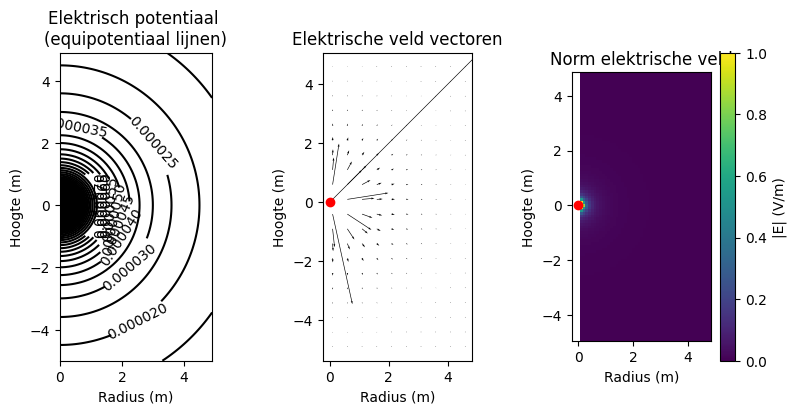

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

Index voor z = 0 m: 50


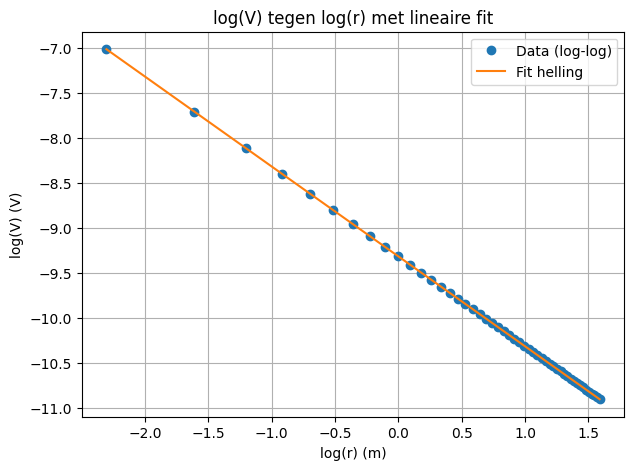

Het exponent in de relatie V ~ r^n is: n = -1.000


In [3]:
#opdracht 1.1
idx_z0 = np.argmin(np.abs(z - 0))
print("Index voor z = 0 m:", idx_z0)

#opdracht 1.2
#potentiaal op z = 0
V_z0 = V[idx_z0, :]

#alleen r > 0
r_pos = r[1:]
V_pos = V_z0[1:]

#Berekening log(r) en log(V)
log_r = np.log(r_pos)
log_V = np.log(V_pos)

#Fit log(V) = a * log(r) + b
coeffs = np.polyfit(log_r, log_V, 1)
helling, intercept = coeffs

log_V_fit = helling * log_r + intercept

# data + fit plotten
plt.figure(figsize=(7,5))
plt.plot(log_r, log_V, 'o', label='Data (log-log)')
plt.plot(log_r, log_V_fit, '-', label=f'Fit helling')
plt.xlabel("log(r) (m)")
plt.ylabel("log(V) (V)")
plt.title("log(V) tegen log(r) met lineaire fit")
plt.grid(True)
plt.legend()
plt.show()


print(f"Het exponent in de relatie V ~ r^n is: n = {helling:.3f}")



##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

Index voor z = 0 m: 49


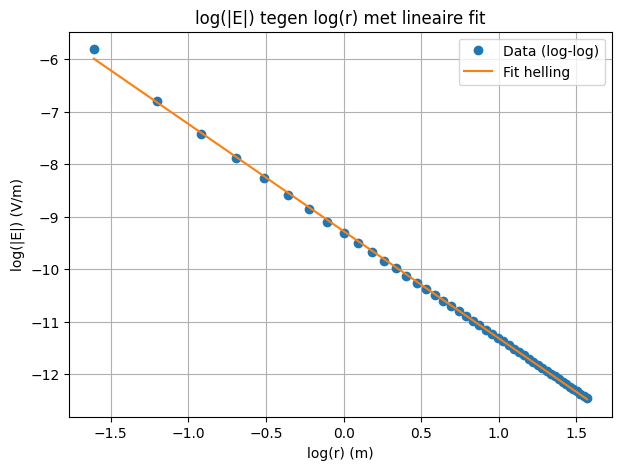

Het exponent in de relatie E ~ r^n is: n = -2.040


In [4]:
# 1.index voor z = 0
idx_z0 = np.argmin(np.abs(z_for_E - 0))
print("Index voor z = 0 m:", idx_z0)

#E-norm op z = 0
E_z0 = normE[idx_z0, :]

#alleen r > 0
r_pos = r_for_E[1:]
E_pos = E_z0[1:]

#Berekening log(r) en log(E)
log_r = np.log(r_pos)
log_E = np.log(E_pos)

#Fit log(E) = a * log(r) + b
coeffs = np.polyfit(log_r, log_E, 1)
helling, intercept = coeffs

log_E_fit = helling * log_r + intercept

#data + fit plotten
plt.figure(figsize=(7,5))
plt.plot(log_r, log_E, 'o', label='Data (log-log)')
plt.plot(log_r, log_E_fit, '-', label=f'Fit helling')
plt.xlabel("log(r) (m)")
plt.ylabel("log(|E|) (V/m)")
plt.title("log(|E|) tegen log(r) met lineaire fit")
plt.grid(True)
plt.legend()
plt.show()


print(f"Het exponent in de relatie E ~ r^n is: n = {helling:.3f}")


### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

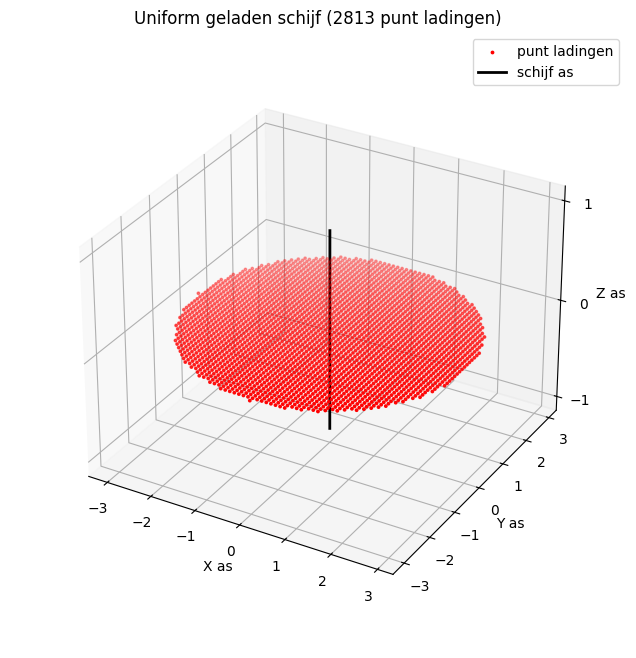

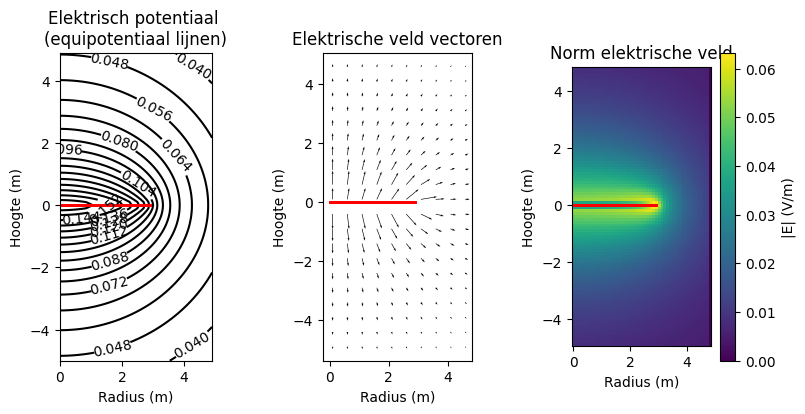

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step   # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

2.1:
De diskradius variabele betekent de radius van de cirkel die geprint word. Als deze naar 0 gaat zal er slechts 1 punt verschijnen op <0,0,0>

2.2:
gridstep beaalt de afstand tussen de punten waarop het potentiaanveld word berekend. Als je gridstep groter maakt dan word de meting meer nauwkeurig maar duurt het langer om te runnen en als je e gridstep groter maakt zla dat het tegenovergestelde effect hebben en de geplotten cirkel steeds blokkeriger maken

2.3:
Wij hebben voor de inter_charge_distance gekozen en wij zagen dat als die kleiner word dan krijg je een mooie scheif en als die groter word dan zijn er alleen maar een paar punten in het plot

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
# Totale lading
Q_tot = number_point_charges_on_disk * charge_one_point

# Opp
A = np.pi * disk_radius**2

# Oppervlakteladingsdichtheid
sigma = Q_tot / A

print(f"Oppervlakteladingsdichtheid σ = {sigma:.3e} C/m^2")


Oppervlakteladingsdichtheid σ = 9.949e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

Text(0, 0.5, 'Potentiaal V (V)')

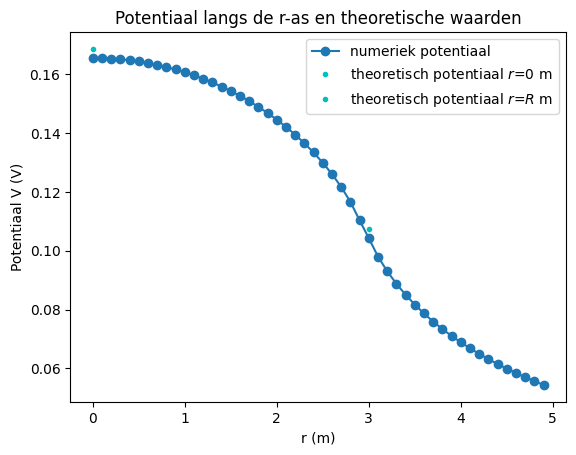

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.

idx_z_zero = np.argmin(np.abs(z - 0))   # index voor z = 0 m

V_0 = sigma * disk_radius / (2 * epsilon0)   # theoretisch potentiaal op r = 0

V_R = sigma * disk_radius / (np.pi * epsilon0)   # theoretisch potentiaal op r = R
r_R = disk_radius   # straal van de schijf

plt.title(f"Potentiaal langs de r-as en theoretische waarden")
plt.plot(r, V[idx_z_zero, :], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("r (m)")
plt.ylabel("Potentiaal V (V)")



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


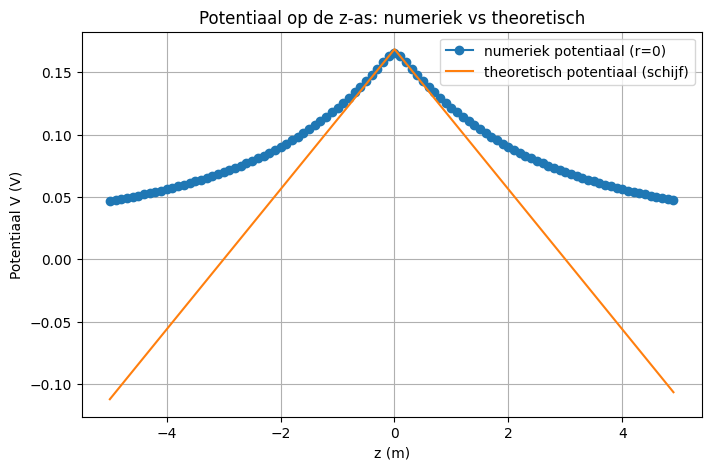

In [9]:
#Numeriek potentiaal op de z-as
idx_r_zero = np.argmin(np.abs(r - 0))     # index voor r = 0
V_z = V[:, idx_r_zero]                    # potentiaal als functie van z

#Theoretisch potentiaal op de as van een schijf
#    V(z, r=0) = σ/(2ε0) * (R - |z|)
V_theory = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z))

#Plotten en opslaan
plt.figure(figsize=(8,5))
plt.title("Potentiaal op de z-as: numeriek vs theoretisch")
plt.plot(z, V_z, "o-", label="numeriek potentiaal (r=0)")
plt.plot(z, V_theory, "-", label="theoretisch potentiaal (schijf)")
plt.xlabel("z (m)")
plt.ylabel("Potentiaal V (V)")
plt.legend()
plt.grid(True)

plt.savefig("vraag_2d_potentiaal_z_as.png", dpi=300)
#plt.savefig("vraag_2d_naar_2g_potentiaal_z_as.png", dpi=300) #radius veranderd naar 5 voor opdracht 2g
plt.show()


#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

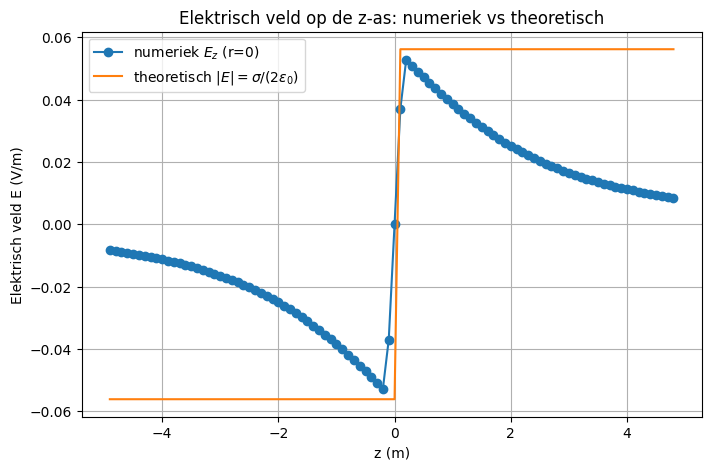

In [10]:
#elektrisch veld op de z-as (r = 0)
idx_r_zero = np.argmin(np.abs(r_for_E - 0))   # index voor r = 0
Ez_z = Ez[:, idx_r_zero]                      # z-component van E langs de z-as

#Theoretisch elektrisch veld van een oneindig geladen oppervlak
#    |E| = σ / (2 ε0)
E_theory = np.sign(z_for_E) * sigma / (2 * epsilon0)

E_theory_array = np.ones_like(z_for_E) * E_theory

#Plotten en opslaan
plt.figure(figsize=(8,5))
plt.title("Elektrisch veld op de z-as: numeriek vs theoretisch")
plt.plot(z_for_E, Ez_z, "o-", label="numeriek $E_z$ (r=0)")
plt.plot(z_for_E, E_theory_array, "-", label=r"theoretisch $|E| = \sigma/(2\epsilon_0)$")
plt.xlabel("z (m)")
plt.ylabel("Elektrisch veld E (V/m)")
plt.legend()
plt.grid(True)

plt.savefig("vraag_2e_electrisch_veld_z_as.png", dpi=300)
#plt.savefig("vraag_2e_naar_2g_electrisch_veld_z_as.png", dpi=300)  #radius veranderd naar 5 voor opdracht 2g
plt.show()


#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

2f.1:
Het elektrische veld van de schijf lijkt het meest op dat van een oneindig geladen plaat vlak bij het oppervlak van de schijf, 
dus wanneer je op de as zit (r = 0), en de afstand tot de schijf klein is vergeleken met de straal (z ≪ R).
In dat gebied lijkt de schijf lokaal oneindig groot, waardoor het veld bijna constant wordt, net zoals bij een oneindig vlak.

Numeriek veld (blauwe lijn):
- Het veld is niet constant.
- Dicht bij z = 0 zit het veld in de buurt van de theoretische waarde.
- Als je verder van de schijf af gaat, neemt het veld af.
Dit komt doordat onze schijf eindig is. Ver van de schijf zie je niet meer een groot oppervlak, maar meer een puntbron, waardoor het veld kleiner wordt.

Theoretisch veld (oranje lijn):
- Dit is een horizontale lijn, want voor een oneindig geladen plaat is
$|E|=\frac{\sigma }{2\epsilon _0}$
- en dat is overal constant en onafhankelijk van z.




#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

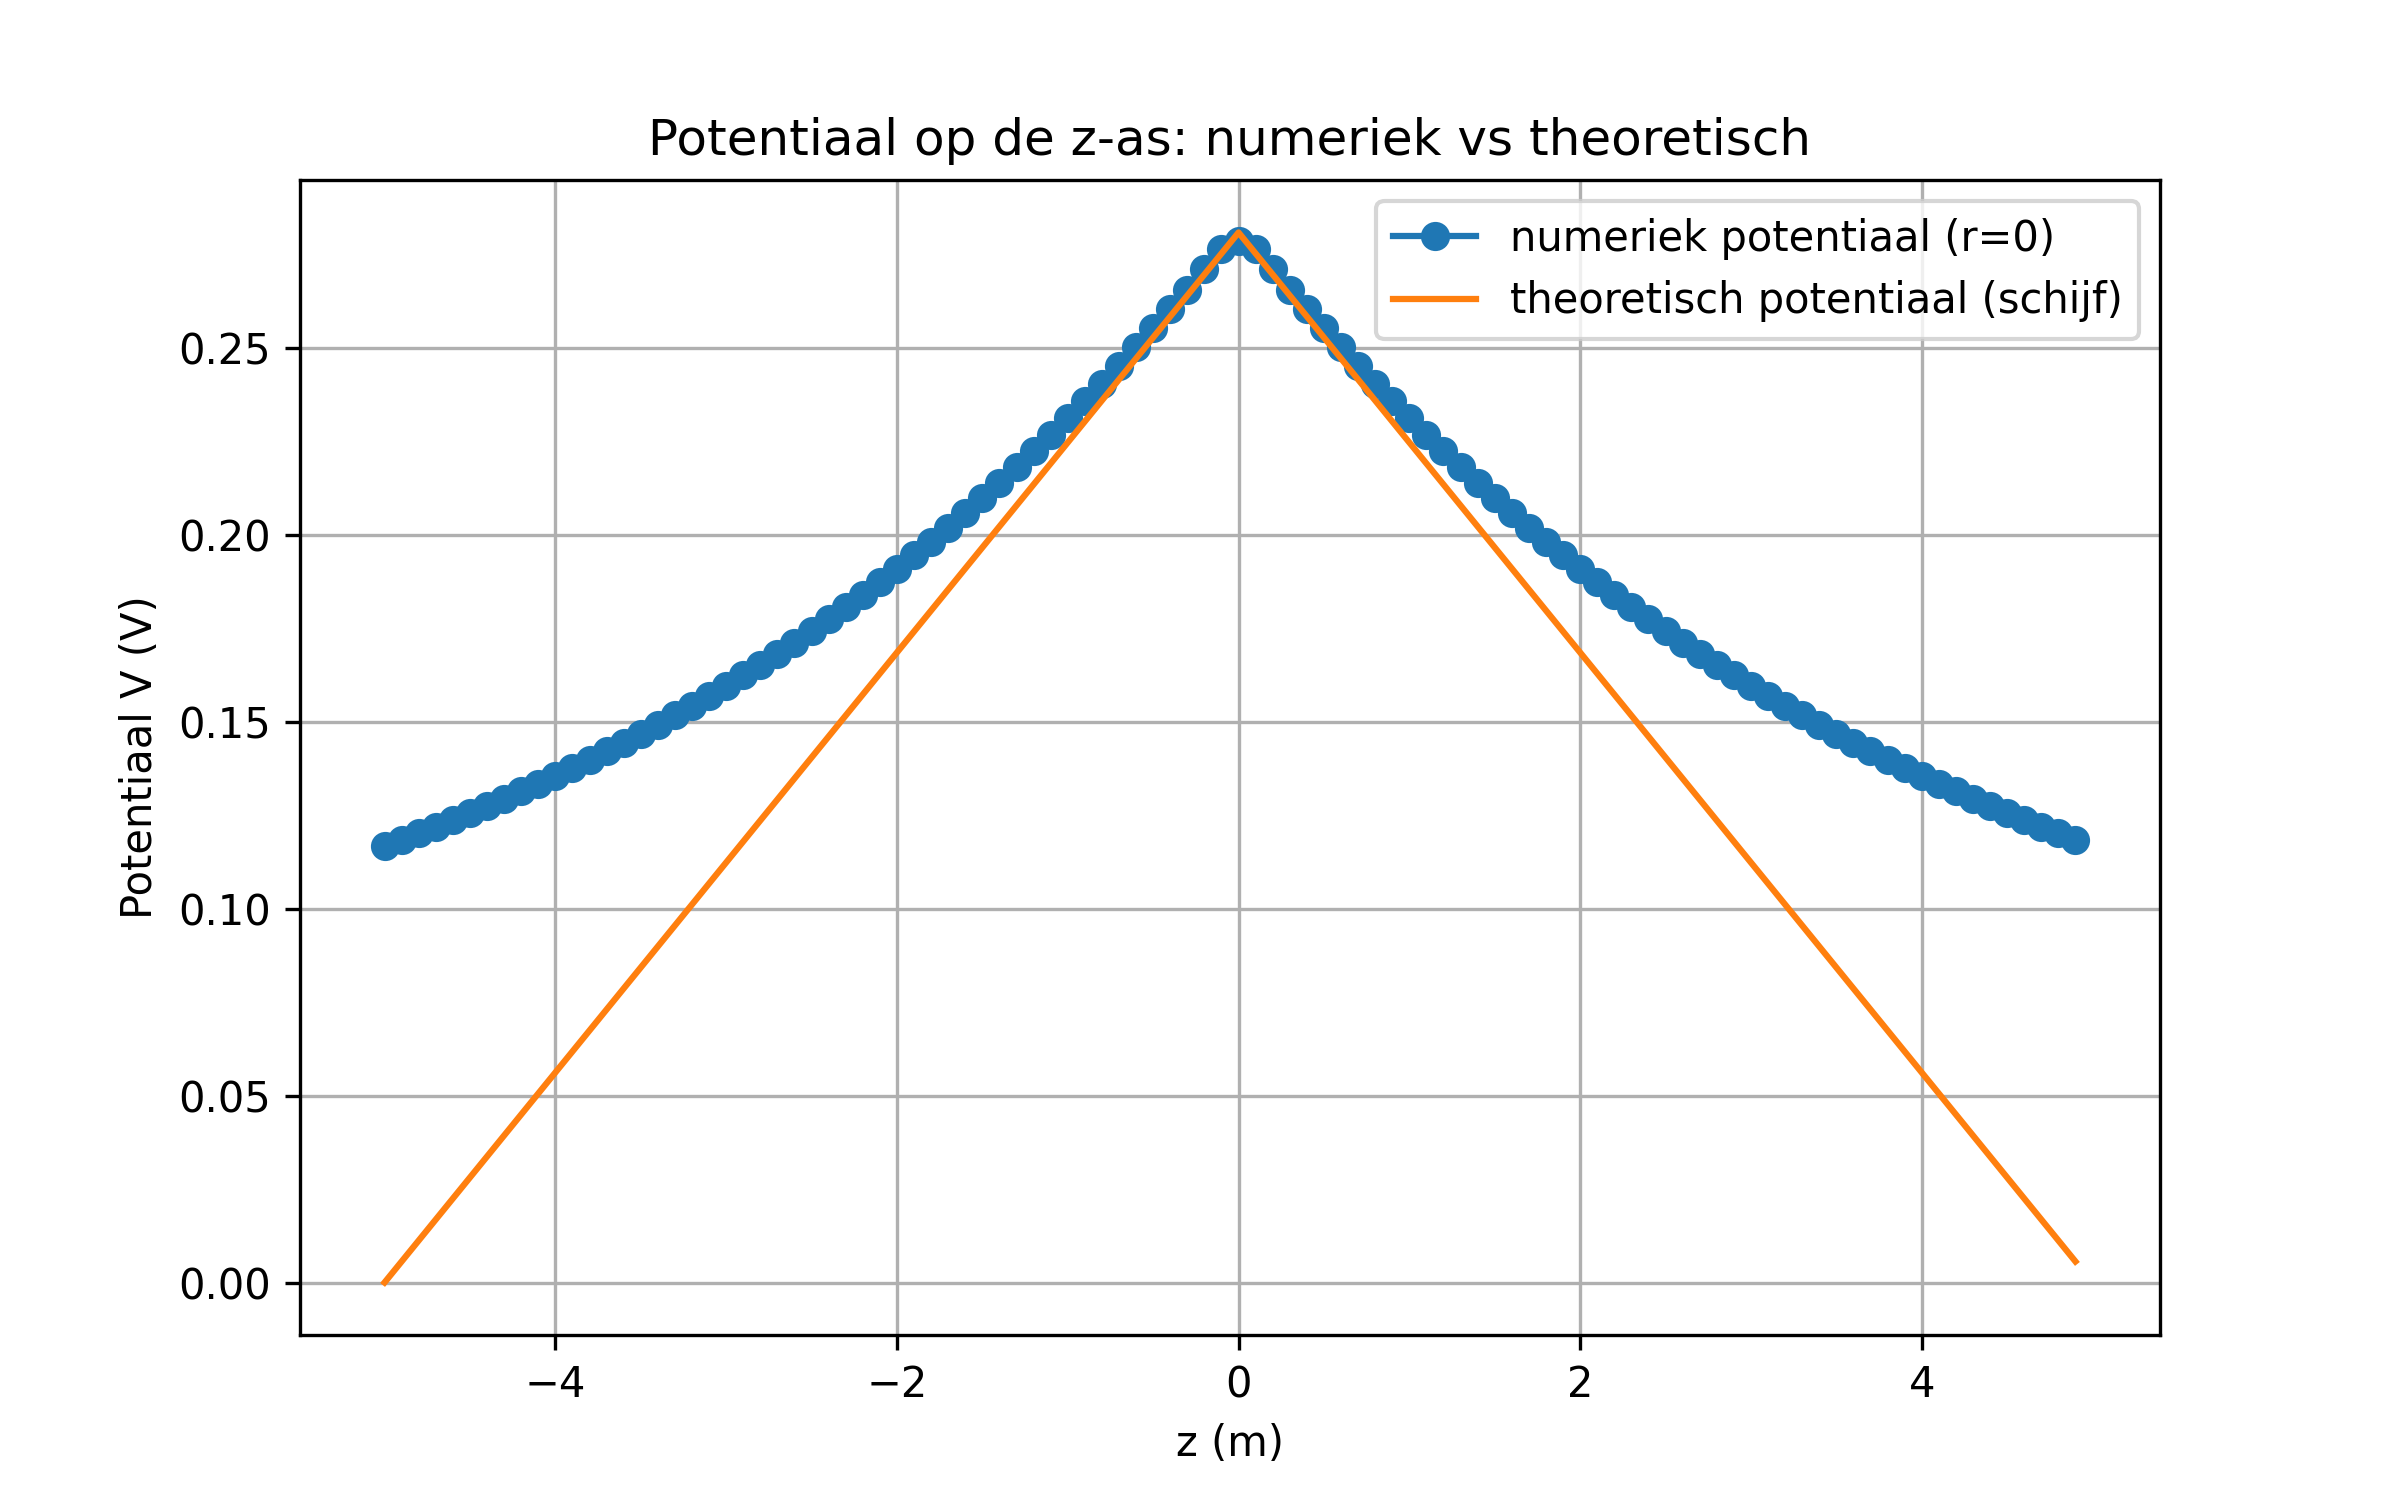

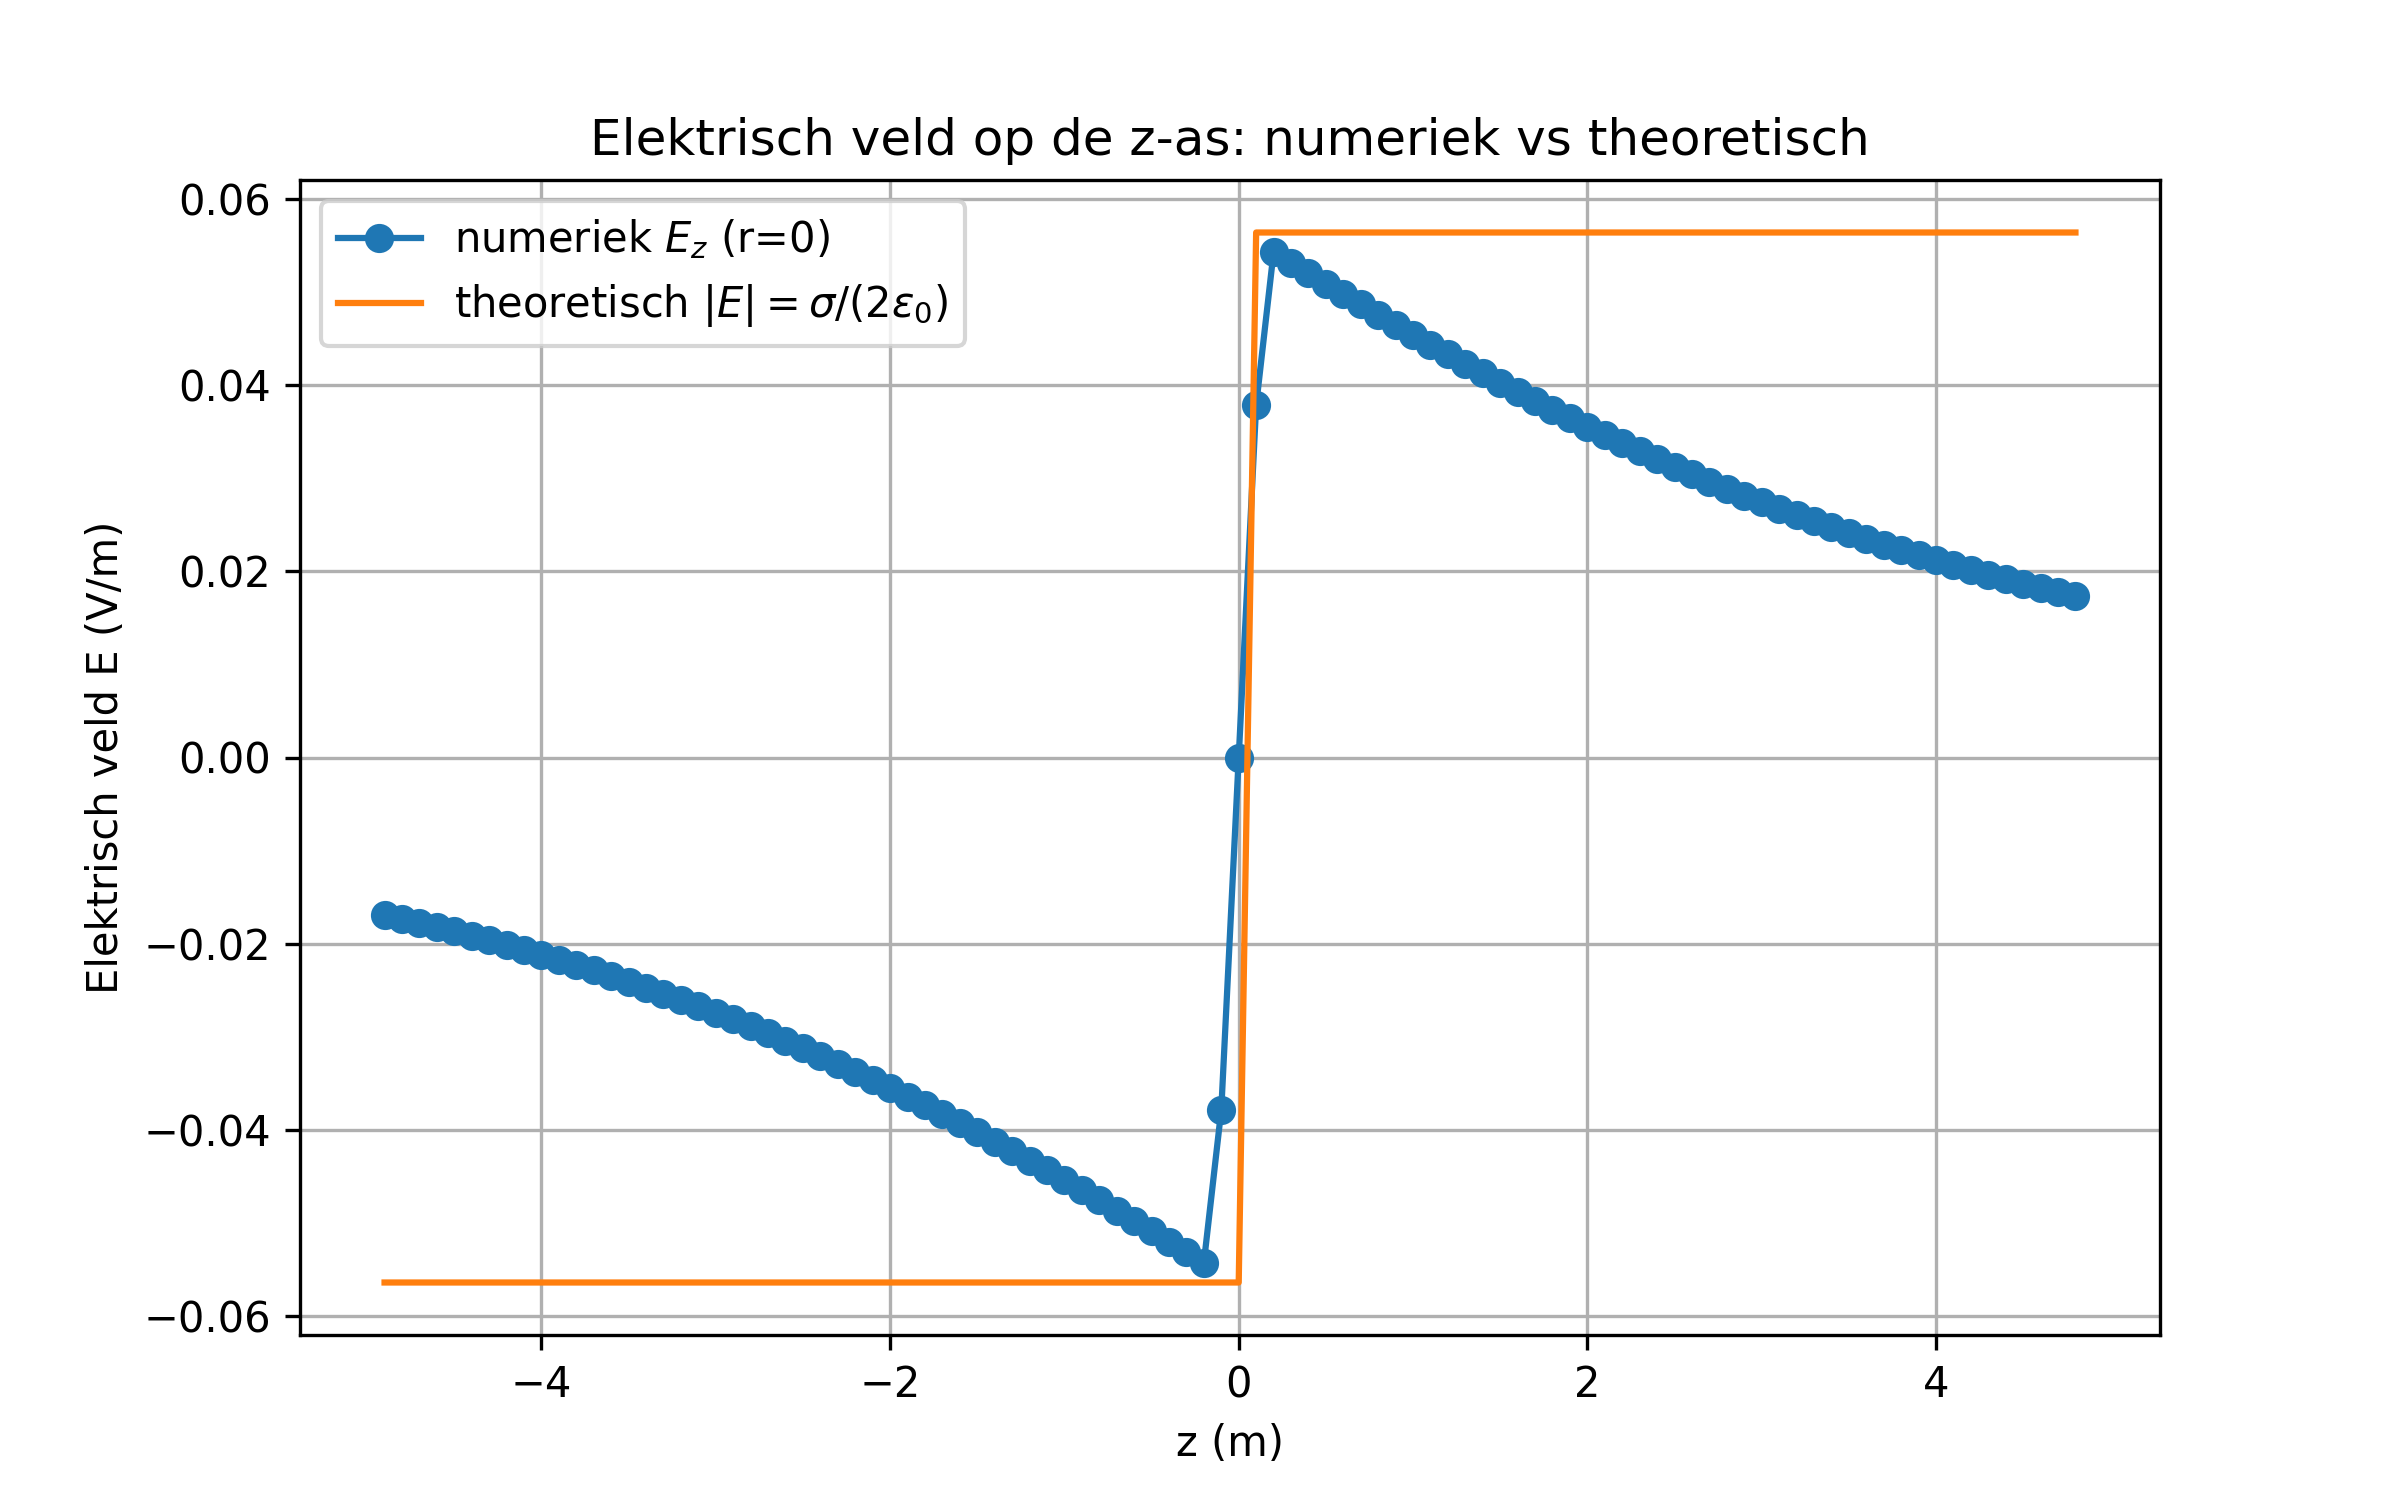

In [11]:
display(Image("vraag_2d_naar_2g_potentiaal_z_as.png"))
display(Image("vraag_2e_naar_2g_electrisch_veld_z_as.png"))

##### Antwoorden 2g

wij hebben de straal veranderd naar 5 waardoor de numerieke waardes van de grafiek beter in de buurt komen van de theoretische waardes. Dit is ook zichtbaar in de plaatjes want ik het eerste plaatje overlapt de numeriek waarde de theoretische fit langer dan bij 3 en in het tweede plaatje kom de numerieke waarde dichter bij de theoretische waarde. dit komt doordat de schijf groter is en het potentiaal dus dichter bij oneindig in de buurt komt.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h
- de hoogte moet ongeveer 2,06 keer de radius zijn
- Berekening:
- Voor een oneindig geladen plaat geldt:
$E_{\infty }=\frac{\sigma }{2\epsilon _0}$
- De eis is dan:
$E(z)=0,1\, E_{\infty }$
- Voor de schijf op hoogte z boven het midden:
$E(z)=\frac{\sigma }{2\epsilon _0}\left[ 1-\frac{z}{\sqrt{R^2+z^2}}\right] $
- $1-\frac{z}{\sqrt{R^2+z^2}}=0,1$
- $z=\sqrt{\frac{0,81}{0,19}}\, R\approx 2,06\, R$












### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

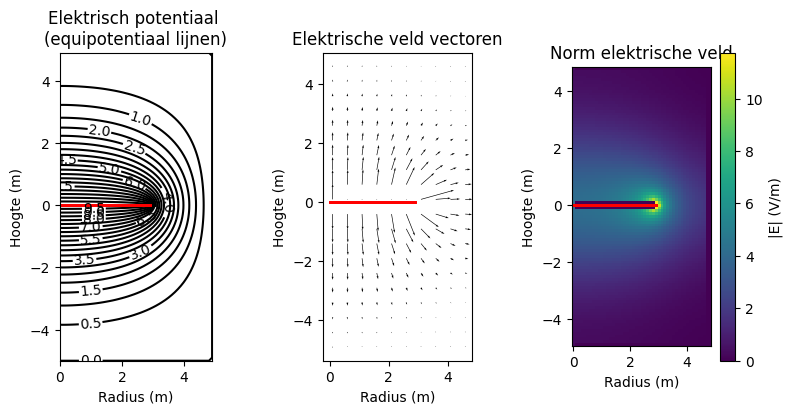

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

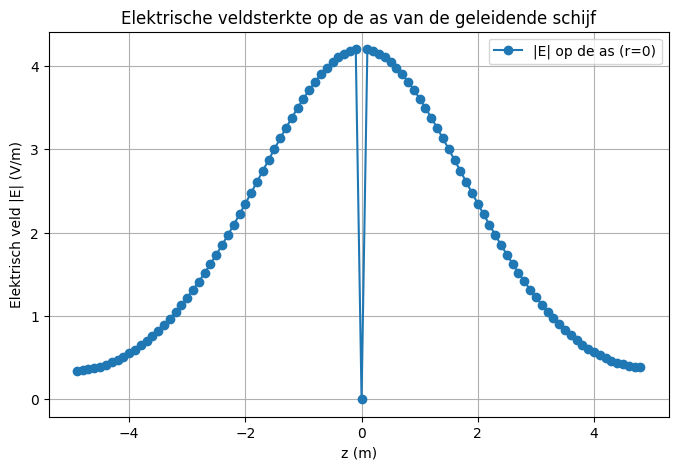

Elektrisch veld heel dicht bij het midden van de schijf (r=0, z≈0): 1.521e-05 V/m


In [13]:
#index voor r = 0 (as van de schijf)
idx_r_zero = np.argmin(np.abs(r_for_E - 0))

#Elektrisch veld op de as
Ez_axis = Ez[:, idx_r_zero]
normE_axis = normE[:, idx_r_zero]

#Plot elektrische veld op as
plt.figure(figsize=(8,5))
plt.title("Elektrische veldsterkte op de as van de geleidende schijf")
plt.plot(z_for_E, normE_axis, "o-", label="|E| op de as (r=0)")
plt.xlabel("z (m)")
plt.ylabel("Elektrisch veld |E| (V/m)")
plt.grid(True)
plt.legend()
plt.show()

#veldsterkte heel dicht bij het midden (z ≈ 0)
idx_z_zero = np.argmin(np.abs(z_for_E - 0))
E_center = normE_axis[idx_z_zero]

print(f"Elektrisch veld heel dicht bij het midden van de schijf (r=0, z≈0): {E_center:.3e} V/m")


#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

$\sigma =\epsilon _0\, E_z$



In [14]:
#index r = 0
idx_r_zero = np.argmin(np.abs(r_for_E - 0))

#index z net boven de schijf(limiet naar nul van boven)
idx_z_zero = np.argmin(np.abs(z_for_E - 0))

#z-component van het elektrische veld net boven het oppervlak
Ez_center = Ez[idx_z_zero, idx_r_zero]

#oppervlaktelading via sigma = epsilon0 * E_z
sigma_center = epsilon0 * Ez_center

print(f"Benadering van de oppervlaktelading in het midden van de schijf:\u03C3(0,0) ≈ {sigma_center:.3e} C/m^2")



Benadering van de oppervlaktelading in het midden van de schijf:σ(0,0) ≈ 1.347e-16 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Totale lading op de schijf (benaderd door ver weg veld): Q ≈ 9.841e-10 C
σ in het centrum van de geleidende schijf:      σ_center ≈ 1.347e-16 C/m^2
σ van een uniform geladen schijf met lading Q:  σ_uniform ≈ 3.481e-11 C/m^2


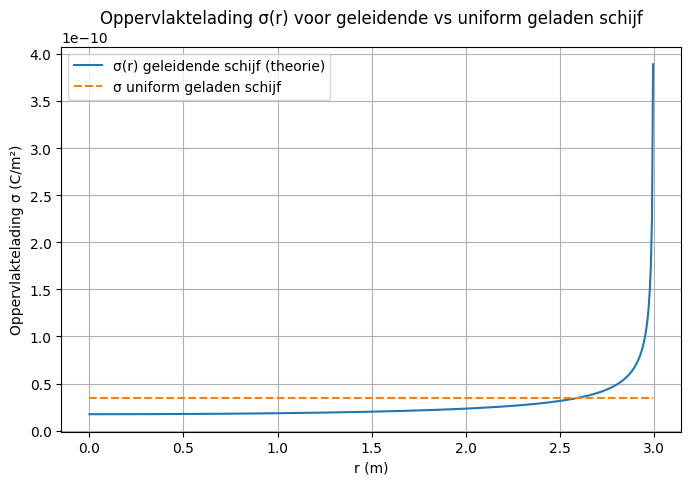

In [15]:
#opdracht 3c.1
#punt ver weg op de z-as
idx_r_zero = np.argmin(np.abs(r_for_E - 0))
Ez_axis = Ez[:, idx_r_zero]

z_far = z_for_E[-1]
Ez_far = Ez_axis[-1]

Q = 4 * np.pi * epsilon0 * z_far**2 * Ez_far

print(f"Totale lading op de schijf (benaderd door ver weg veld): Q ≈ {Q:.3e} C")

#opdracht 3c.2
# σ in het centrum (uit vraag 3b)
idx_z_zero = np.argmin(np.abs(z_for_E - 0))
Ez_center = Ez[idx_z_zero, idx_r_zero]
sigma_center = epsilon0 * Ez_center

# σ van een uniform geladen schijf met dezelfde totale lading Q
sigma_uniform = Q / (np.pi * disk_radius**2)

print(f"\u03C3 in het centrum van de geleidende schijf:      \u03C3_center ≈ {sigma_center:.3e} C/m^2")
print(f"\u03C3 van een uniform geladen schijf met lading Q:  \u03C3_uniform ≈ {sigma_uniform:.3e} C/m^2")

#opdracht 3c.3,3c.4
# r-as voor de schijf
r_vals = np.linspace(0, disk_radius*0.999, 500)  # net niet tot R om deling door 0 te vermijden

sigma_conducting = Q / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r_vals**2))

sigma_uniform_array = np.ones_like(r_vals) * sigma_uniform

plt.figure(figsize=(8,5))
plt.title("Oppervlaktelading \u03C3(r) voor geleidende vs uniform geladen schijf")
plt.plot(r_vals, sigma_conducting, label="\u03C3(r) geleidende schijf (theorie)")
plt.plot(r_vals, sigma_uniform_array, "--", label="\u03C3 uniform geladen schijf")
plt.xlabel("r (m)")
plt.ylabel("Oppervlaktelading \u03C3 (C/m²)")
plt.legend()
plt.grid(True)
plt.show()


#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
#maximum van |E|
E_max = np.max(normE)

#waar maximum zich bevindt
idx_max = np.unravel_index(np.argmax(normE), normE.shape)
idx_z_max, idx_r_max = idx_max

z_max = z_for_E[idx_z_max]
r_max = r_for_E[idx_r_max]

#Elektrisch veld midden van de schijf
idx_r_center = np.argmin(np.abs(r_for_E - 0))
idx_z_center = np.argmin(np.abs(z_for_E - 0))
E_center = normE[idx_z_center, idx_r_center]

ratio = E_max / E_center

# alles printen
print("Maximale elektrische veldsterkte in de simulatie:")
print(f"  |E|_max   = {E_max:.3e} V/m")
print(f"  Locatie   = r = {r_max:.3e} m, z = {z_max:.3e} m")
print()
print("Elektrisch veld in het midden van de schijf (r=0, z≈0):")
print(f"  |E|_center = {E_center:.3e} V/m")
print()
print("Verhouding tussen maximum en centrum:")
print(f"  |E|_max / |E|_center = {ratio:.3f}")


Maximale elektrische veldsterkte in de simulatie:
  |E|_max   = 1.175e+01 V/m
  Locatie   = r = 3.000e+00 m, z = 1.000e-01 m

Elektrisch veld in het midden van de schijf (r=0, z≈0):
  |E|_center = 1.521e-05 V/m

Verhouding tussen maximum en centrum:
  |E|_max / |E|_center = 772488.589


##### Antwoord 3d.5

Wanneer we naar het elektrische veld rond een geleidende schijf kijken, zien we dat het veld niet overal even sterk is. 
Vooral aan de rand van de schijf ontstaat een opvallend hoog elektrisch veld.
Dit komt doordat de ladingen op een geleider zich vrij kunnen verplaatsen en elkaar afstoten. 
In het binnenste van de schijf is er relatief veel ruimte, waardoor de ladingen daar minder dicht op elkaar zitten. 
Aan de rand is echter minder oppervlak beschikbaar en kunnen de ladingen niet verder naar buiten uitwijken. 
Daardoor hopen ze zich op in de buurt van de rand. 
Deze ophoping van lading zorgt ervoor dat de veldlijnen dichter bij elkaar komen te liggen, wat resulteert in een veel sterker elektrisch veld dan in het midden van de schijf.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

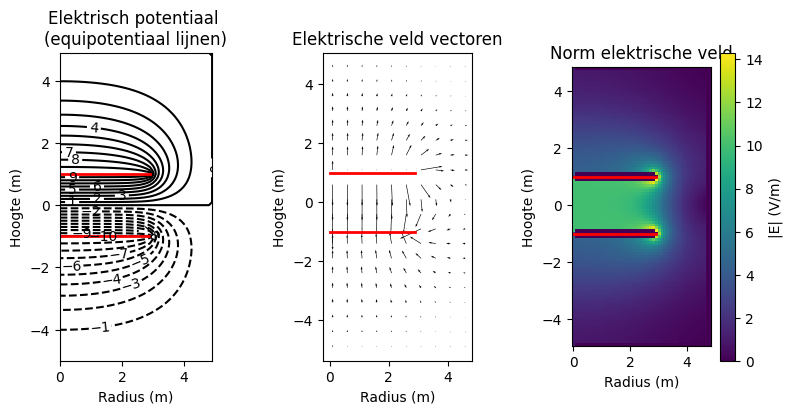

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


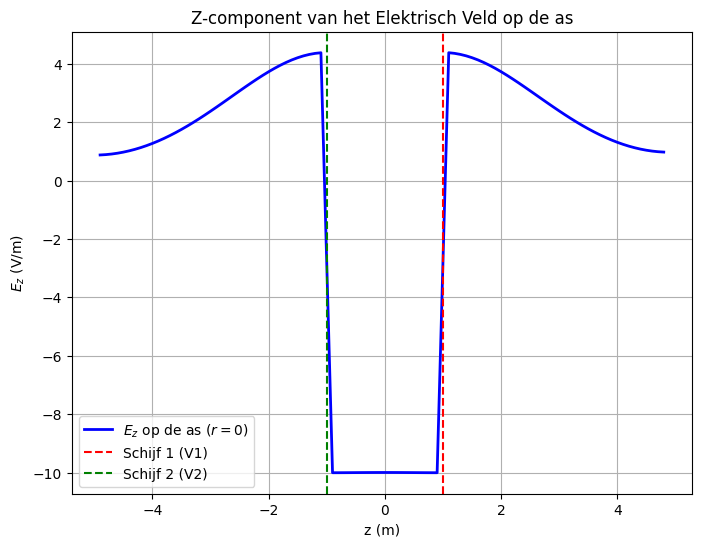

In [18]:
#opgave 4a

import matplotlib.pyplot as plt

#as van de schijven
index_as = 0 


Ez_as = Ez[:, index_as]

#plot en grafiek
plt.figure(figsize=(8, 6))
plt.plot(z_for_E, Ez_as, label='$E_z$ op de as ($r=0$)', color='blue', linewidth=2)
plt.axvline(x=z_pos_disk1, color='red', linestyle='--', label='Schijf 1 (V1)')
plt.axvline(x=z_pos_disk2, color='green', linestyle='--', label='Schijf 2 (V2)')
plt.title('Z-component van het Elektrisch Veld op de as')
plt.xlabel('z (m)')
plt.ylabel('$E_z$ (V/m)')
plt.grid(True)
plt.legend()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b


1. Tussen de twee platen zit geen ladingsdichtheid, want hangs af van van de twee $z$-assen geplaatst, dus (laplace vergelijking)

$$
\nabla^2 V = 0
$$

$$
\frac{d^2 V}{dz^2} = 0
$$

intergreren: lineair potentiaal naar uniform veld

$$
E = -\frac{dV}{dz}
$$

$$
\frac{dV}{dz} = N \quad (N = \text{const})
$$

$$
V(z) = Nz + M \quad (M = \text{const})
$$

$$
E = -N
$$

De afstand tussen de twee platen is $d$ en ze liggen symmetrisch om de oorsprong $O$,  
dus de randen liggen op $z = \pm \frac{d}{2}$

$$
z = -\frac{d}{2} \quad \text{en} \quad z = \frac{d}{2}
$$

$$
V_1 = V\!\left(\frac{d}{2}\right) = \frac{d}{2}N + M
$$

$$
V_2 = V\!\left(-\frac{d}{2}\right) = -\frac{d}{2}N + M
$$

$$
V_1 - V_2 = \frac{d}{2}N + \frac{d}{2}N = dN
$$

$$
\Rightarrow N = \frac{V_1 - V_2}{d}
$$

$$
E = \frac{V_2 - V_1}{d}
$$

$$
E = \frac{-10 - 10}{2} = -10 \,\text{V/m}
$$

theoretisch elektrisch veld regio's: $E(z)=\begin{cases}
0 & |z|>\frac{d}{2} \\
\frac{V_2 - V_1}{d} & |z|<\frac{d}{2}
\end{cases}$


![figure 5.1](schets_4b.jpeg)

2. het numerieke berekend elektrisch veld komt grootendeels om met het theoretische. 

3. Tussen twee geleidende schijven op verschillende potentiaal ontstaat in het midden 
$(r=0, z=0)$ een bijna uniform elektrisch veld. De veldsterkte is daar ongeveer constant en wordt goed benaderd door
$$
E \approx \frac{V_2 - V_1}{d}.
$$

Bij één enkele geleidende schijf op hetzelfde potentiaal is het elektrisch veld daarentegen niet uniform. Het spreidt zich uit in de ruimte en neemt snel af met de afstand tot de schijf.
Het voordeel van de dubbele-schijfconfiguratie is dus dat ze een sterker en veel homogener elektrisch veld creëert tussen de schijven.


#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
import numpy as np

# Gegevens
epsilon0 = 8.854e-12  
R = 3                  
V1 = 0                  
V2 = 10                
V = V2 - V1
E_plaat1 = V / 0.1      
E_plaat2 = -E_plaat1
A = np.pi * R**2        

# Oppervlaktelading
sigma1 = E_plaat1 * epsilon0
sigma2 = E_plaat2 * epsilon0

# Totale lading op elke schijf verwacht
Q_plaat1 = sigma1 * A
Q_plaat2 = sigma2 * A
Qtot = Q_plaat1 + Q_plaat2

# Capaciteit
C = Q_plaat1 / V


print(f"Verwachte oppervlakte lading op plaat 1: {sigma1:.2e} C/m^2")
print(f"Totale lading op plaat 1: {Q_plaat1:.2e} C")
print(f"Totale lading op plaat 2: {Q_plaat2:.2e} C")
print(f"Verwachte totale lading: {Qtot:.2e} C")
print(f"Capaciteit: {C:.2e} F")

Verwachte oppervlakte lading op plaat 1: 8.85e-10 C/m^2
Totale lading op plaat 1: 2.50e-08 C
Totale lading op plaat 2: -2.50e-08 C
Verwachte totale lading: 0.00e+00 C
Capaciteit: 2.50e-09 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d


1. Voor ideale oneindige platen is de buitenkant exact ongeladen, dus gelijk aan 0. Maar bij echte platen kunnen kleine rand-effecten optreden. 


2. Het elektrische veld bij het oppervlak van een geleider staat loodrecht op het oppervlak en heeft een sterkte van 
$$
E = \frac{\sigma}{\varepsilon_0}
$$
waar $\sigma$ de oppervlakteladingdichtheid is. Binnen de geleider is het elektrisch veld nul. Hierdoor vrije elektronen zich zo verdelen dat dit loodrechte veld ontstaat.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
##### Antwoorden 4d
import numpy as np

# Indexen
idx_axis = 0
idx_z2 = np.argmin(np.abs(z_for_E - z_pos_disk2))
idx_below = max(idx_z2 - 1, 0)
idx_above = min(idx_z2 + 1, len(z_for_E) - 1)

# Ez waarden
# onder de schijf
Ez_below = Ez[idx_below, idx_axis] 
# boven de schijf
Ez_above = Ez[idx_above, idx_axis]  

# Ladingsdichtheid
sigma_below = epsilon0 * Ez_below
sigma_above = epsilon0 * Ez_above

# Print overzichtelijke tabel
print("Numeriek berekende waarden op de as (r ~ 0) nabij de onderste schijf")
print("-------------------------------------------------------------------")
print(f"{'Locatie':<20}{'z (m)':<10}{'Ez (V/m)':<15}{'sigma (C/m^2)':<20}")
print("-------------------------------------------------------------------")
print(f"{'Net onder schijf':<20}{z_for_E[idx_below]:<10.3f}{Ez_below:<15.3e}{sigma_below:<20.3e}")
print(f"{'Net boven schijf':<20}{z_for_E[idx_above]:<10.3f}{Ez_above:<15.3e}{sigma_above:<20.3e}")


Numeriek berekende waarden op de as (r ~ 0) nabij de onderste schijf
-------------------------------------------------------------------
Locatie             z (m)     Ez (V/m)       sigma (C/m^2)       
-------------------------------------------------------------------
Net onder schijf    -1.100    4.377e+00      3.875e-11           
Net boven schijf    -0.900    -1.000e+01     -8.858e-11          


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. De eenvoudige berekening uit 4c (met uniforme lading) overschat of negeert deze rand-effecten. De daadwerkelijke lading is dus iets anders verdeeld, maar het totaal blijft ongeveer gelijk.
2. Door randeffecten kunnen de platen iets meer lading opslaan voor dezelfde spanning. Hierdoor is de werkelijke capaciteit iets hoger dan de theoretische waarde $C = \varepsilon_0 A / d$, dus het antwoord bij 4c is een onderschatting.
3. Kleinere afstand dus sterker veld, hogere ladingsdichtheid en grotere capaciteit.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [21]:
def vlakkeplaat(A, d, epsilon_r=1):
    epsilon_0 = 8.854e-12
    C = epsilon_0 * epsilon_r * A / d
    return C

def cilinder(r1, r2, L, epsilon_r=1):
    import math
    epsilon_0 = 8.854e-12
    C = (2 * math.pi * epsilon_0 * epsilon_r * L) / math.log(r2 / r1)
    return C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
###
import numpy as np

# Constanten
epsilon_0 = 8.854e-12
eps_lucht = 1.0
eps_water = 80.0
eps_pvc = 3.0

# funcities 5a
def vlakkeplaat(A, d, epsilon_r=1):
    epsilon_0 = 8.854e-12
    C = epsilon_0 * epsilon_r * A / d
    return C

def cilinder(r1, r2, L, epsilon_r=1):
    import math
    epsilon_0 = 8.854e-12
    C = (2 * math.pi * epsilon_0 * epsilon_r * L) / math.log(r2 / r1)
    return C



# vraag 1
A_plaat = 0.1 * 0.1  
d_plaat = 0.001      
C1_lucht = vlakkeplaat(A_plaat, d_plaat, eps_lucht)

# vraag 2
r1_cil = 0.0045      
r2_cil = 0.0050      
L_cil = 0.1          
C2_lucht = cilinder(r1_cil, r2_cil, L_cil, eps_lucht)

# Vraag 3
C1_dubbel_d = vlakkeplaat(A_plaat, 2 * d_plaat, eps_lucht)

r2_nieuw = r1_cil + 2 * (r2_cil - r1_cil)
C2_dubbel_d = cilinder(r1_cil, r2_nieuw, L_cil, eps_lucht)

# Vraag 4
C1_water = vlakkeplaat(A_plaat, d_plaat, eps_water)
C2_water = cilinder(r1_cil, r2_cil, L_cil, eps_water)

# Vraag 5
C1_pvc = vlakkeplaat(A_plaat, d_plaat, eps_pvc)
C2_pvc = cilinder(r1_cil, r2_cil, L_cil, eps_pvc)


def print_resultaat(titel, c_plaat, c_cil):
    print(f"\n--- {titel} ---")
    print(f"{'Type Condensator':<20} | {'Capaciteit (Farad)':<20} | {'Capaciteit (pF)':<15}")
    print("-" * 60)
    print(f"{'Vlakke plaat':<20} | {c_plaat:<20.4e} | {c_plaat*1e12:<15.2f} pF")
    print(f"{'Cilinder':<20} | {c_cil:<20.4e} | {c_cil*1e12:<15.2f} pF")


print_resultaat("vraag 1 en 2 (lucht)", C1_lucht, C2_lucht)
print_resultaat("vraag 3 Afstand (d) verdubbeld", C1_dubbel_d, C2_dubbel_d)
print_resultaat("vraag 4 (ater)", C1_water, C2_water)
print_resultaat("vraag 5 (PVC)", C1_pvc, C2_pvc)



--- vraag 1 en 2 (lucht) ---
Type Condensator     | Capaciteit (Farad)   | Capaciteit (pF)
------------------------------------------------------------
Vlakke plaat         | 8.8540e-11           | 88.54           pF
Cilinder             | 5.2801e-11           | 52.80           pF

--- vraag 3 Afstand (d) verdubbeld ---
Type Condensator     | Capaciteit (Farad)   | Capaciteit (pF)
------------------------------------------------------------
Vlakke plaat         | 4.4270e-11           | 44.27           pF
Cilinder             | 2.7723e-11           | 27.72           pF

--- vraag 4 (ater) ---
Type Condensator     | Capaciteit (Farad)   | Capaciteit (pF)
------------------------------------------------------------
Vlakke plaat         | 7.0832e-09           | 7083.20         pF
Cilinder             | 4.2241e-09           | 4224.07         pF

--- vraag 5 (PVC) ---
Type Condensator     | Capaciteit (Farad)   | Capaciteit (pF)
------------------------------------------------------------
V

#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
###

import math
# functie 5a
def vlakkeplaat(A, d, epsilon_r=1):
    epsilon_0 = 8.854e-12
    C = epsilon_0 * epsilon_r * A / d
    return C

def cilinder(r1, r2, L, epsilon_r=1):
    epsilon_0 = 8.854e-12
    C = (2 * math.pi * epsilon_0 * epsilon_r * L) / math.log(r2 / r1)
    return C

# waarden
C_doel = 1e-6          
epsilon_0 = 8.854e-12
eps_r = 1.0            

# vraag 1 
r1 = 0.0025            
r2 = 0.0030            

L_cilinder = (C_doel * math.log(r2 / r1)) / (2 * math.pi * epsilon_0 * eps_r)

# vraag 2
d_plaat = 0.0005       
breedte = 0.006       

L_vlakkeplaat = (C_doel * d_plaat) / (epsilon_0 * eps_r * breedte)



print(f"1. De benodigde lengte voor de cilinder condensator is: {L_cilinder:.2f} meter.")
print(f"2. De benodigde lengte voor de vlakke plaat condensator is: {L_vlakkeplaat:.2f} meter.")


1. De benodigde lengte voor de cilinder condensator is: 3277.32 meter.
2. De benodigde lengte voor de vlakke plaat condensator is: 9411.94 meter.


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1. De berekende antwoorden uit vraag 5c zijn niet realistisch, omdat de condensatoren honderden meters tot kilometers lang zouden zijn. Dit zou nooit in een elektronisch apparaat passen.

2. Fabrikanten lossen dit op door materialen met een hoge relatieve permittiviteit te gebruiken in plaats van lucht, waardoor de capaciteit direct veel groter wordt. Daarnaast maken ze de afstand tussen de platen extreem klein en rollen ze de lange platen heel strak op of stapelen ze deze in heel veel dunne laagjes, zodat een groot oppervlak toch in een kleine behuizing past.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
###

import numpy as np

# Functie 5a
def vlakkeplaat(A, d, epsilon_r=1):
    epsilon_0 = 8.854e-12
    C = epsilon_0 * epsilon_r * A / d
    return C


# gegevens
snelheid_kmh = 70
snelheid_ms = snelheid_kmh / 3.6  
V = 10000                         
d = 0.001                         
eps_r_water = 80                  
epsilon_0 = 8.854e-12

# vraag 1
massa = 2500  

# vraag 2
energie_trein = 0.5 * massa * (snelheid_ms**2)

# vraag 3
C_nodig = (2 * energie_trein) / (V**2)

# vraag 4
oppervlakte_A = (C_nodig * d) / (epsilon_0 * eps_r_water)

# vraag 5
print("Resultaten Berekening")
print("-" * 40)
print(f"Geschatte massa:          {massa} kg")
print(f"Kinetische energie:       {energie_trein:.2f} Joules")
print(f"Benodigde capaciteit:     {C_nodig:.4f} Farad")
print(f"Benodigd oppervlak (A):   {oppervlakte_A:.2f} m^2")
print("-" * 40)

# vraag 6

print("DIt is niet realistisch want een oppervlakte van ruim 13.000 m² is veel te groot.")
print("In de praktijk wordt dit opgelost door duizenden dunne laagjes op elkaar te stapelen of de platen heel strak op te rollen, zodat een groot oppervlak in een kleine doos past.")

Resultaten Berekening
----------------------------------------
Geschatte massa:          2500 kg
Kinetische energie:       472608.02 Joules
Benodigde capaciteit:     0.0095 Farad
Benodigd oppervlak (A):   13344.48 m^2
----------------------------------------
DIt is niet realistisch want een oppervlakte van ruim 13.000 m² is veel te groot.
In de praktijk wordt dit opgelost door duizenden dunne laagjes op elkaar te stapelen of de platen heel strak op te rollen, zodat een groot oppervlak in een kleine doos past.


##### Antwoorden 5e

Fabrikanten gebruiken speciale materialen die veel meer elektrische lading kunnen opslaan dan gewone lucht. Ze plaatsen de platen ook extreem dicht op elkaar met een heel dunne isolatielaag ertussen. Om alles compact te houden rollen ze de enorme platen heel strak op of stapelen ze duizenden laagjes in een klein blokje waardoor een groot oppervlak toch weinig ruimte inneemt.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

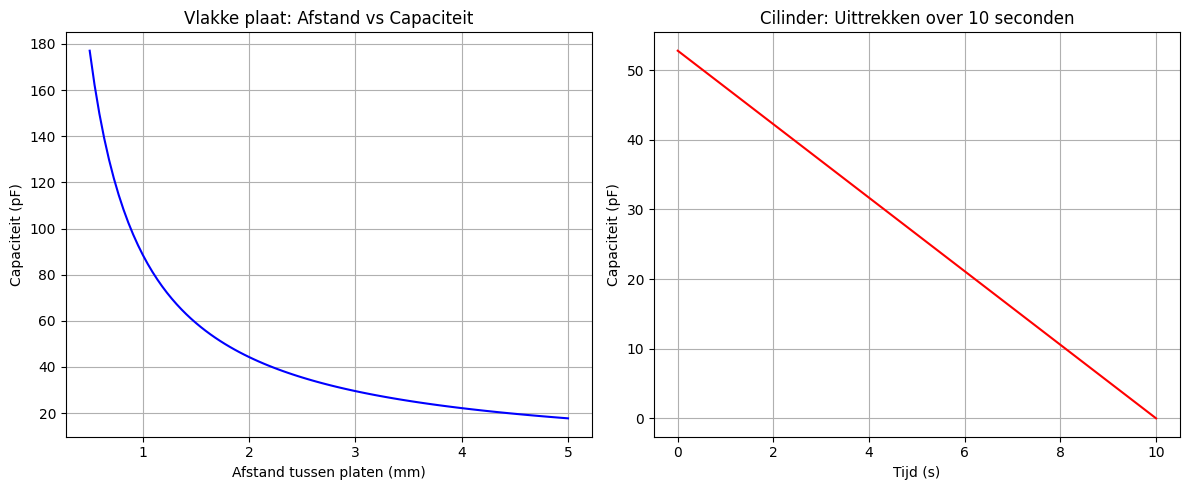

In [ ]:
###
###Jouw code hier###
import numpy as np
import matplotlib.pyplot as plt

# 5a
def vlakkeplaat(A, d, epsilon_r=1):
    epsilon_0 = 8.854e-12
    C = epsilon_0 * epsilon_r * A / d
    return C

def cilinder(r1, r2, L, epsilon_r=1):
    epsilon_0 = 8.854e-12
    # Voorkom delen door nul of log(1) als L=0
    if L <= 0: return 0
    C = (2 * np.pi * epsilon_0 * epsilon_r * L) / np.log(r2 / r1)
    return C

# vraag 1
oppervlak_A = 0.1 * 0.1           
afstanden = np.linspace(0.0005, 0.005, 100)  
capaciteiten_plaat = [vlakkeplaat(oppervlak_A, d) for d in afstanden]

# vraag 2
r1 = 0.0045      
r2 = 0.0050      
L_start = 0.1   
tijd = np.linspace(0, 10, 100)   


lengtes = np.linspace(L_start, 0, 100)
capaciteiten_cilinder = [cilinder(r1, r2, L) for L in lengtes]


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(afstanden * 1000, np.array(capaciteiten_plaat) * 1e12, color='blue')
plt.title("Vlakke plaat: Afstand vs Capaciteit")
plt.xlabel("Afstand tussen platen (mm)")
plt.ylabel("Capaciteit (pF)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(tijd, np.array(capaciteiten_cilinder) * 1e12, color='red')
plt.title("Cilinder: Uittrekken over 10 seconden")
plt.xlabel("Tijd (s)")
plt.ylabel("Capaciteit (pF)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](afbeelding_meetopstelling.png)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a
VRAAG 1 -nieuwe schets van de meetopstelling

![figure 5.1](foto_eindschets.jpeg)

VRAAG 2 - Analytische oplossing voor de capaciteit

We beschouwen een vlakke-plaatcondensator waarbij het overlappende oppervlak
A(L) = b * L is, met:

- b = 0.10 m (breedte van de plaat)
- L = variabele overlap-lengte
- d = 0.0013 m (dikte karton)
- epsilon0 = 8.854e-12 F/m
- epsilon_r = 2.3 (karton)

De capaciteit wordt dan:

    C(L) = epsilon0 * epsilon_r * (b * L) / d

De oude analytische oplossing (karton niet meegerekend) gebruikt epsilon_r = 1.0:

    C_oud(L) = epsilon0 * 1.0 * (b * L) / d

De nieuwe analytische oplossing (karton volledig meegerekend) gebruikt epsilon_r = 2.3:

    C_nieuw(L) = epsilon0 * 2.3 * (b * L) / d


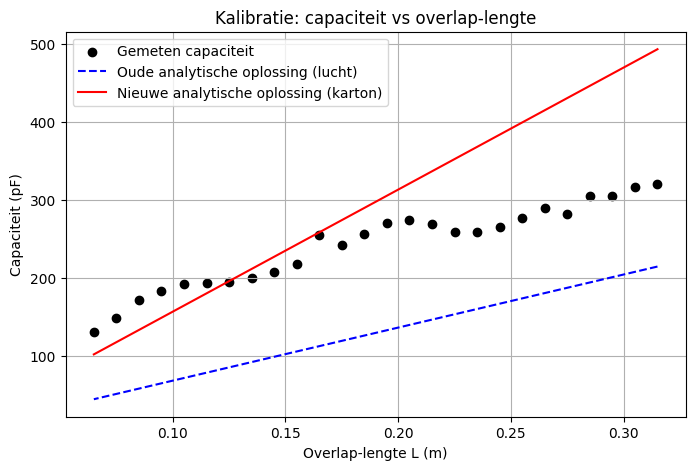

In [26]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie

import numpy as np
import matplotlib.pyplot as plt
epsilon0 = 8.854e-12  # F/m
b = 0.10              # m
d = 0.0013            # m (1.3 mm)
lengtes_verb = np.ones([26])*0.315-np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25])*0.01 #m
capaciteiten_verb = np.array([320.4,316.0,304.7,304.7,282.6,289.6,277.3,265.8,259.0,259.0,269.7,274.0,270.3,256.2,242.2,255.0,217.5,207.0,199.6,194.2,193.6,191.9,183.3,171.0,148.5,130.2])  # pF


def vlakke_plaat(L,epislonr):
    A = L*b
    C = epsilon0*epislonr*A/d
    return C

C_oud = vlakke_plaat(lengtes_verb, 1.0) * 1e12   # naar pF
C_nieuw = vlakke_plaat(lengtes_verb, 2.3) * 1e12 # naar pF


plt.figure(figsize=(8, 5))
plt.scatter(lengtes_verb, capaciteiten_verb, color='black', label='Gemeten capaciteit')
plt.plot(lengtes_verb, C_oud, '--', color='blue', label='Oude analytische oplossing (lucht)')
plt.plot(lengtes_verb, C_nieuw, '-', color='red', label='Nieuwe analytische oplossing (karton)')
plt.xlabel('Overlap-lengte L (m)')
plt.ylabel('Capaciteit (pF)')
plt.title('Kalibratie: capaciteit vs overlap-lengte')
plt.grid(True)
plt.legend()
plt.show()



##### Antwoorden 6a

VRAAG 5 — Beschrijving en verklaring van verschillen tussen de grafieken

1. De oude analytische oplossing (epsilon_r = 1.0) ligt duidelijk onder de meetpunten.
   Dit komt doordat het oude model ervan uitgaat dat er alleen lucht tussen de platen zit.
   In werkelijkheid zit er karton tussen de platen, waardoor de capaciteit groter wordt.

2. De nieuwe analytische oplossing (epsilon_r = 2.3) ligt boven de meetpunten.
   Dit model gaat ervan uit dat het karton perfect contact maakt en het volledige
   overlappende oppervlak exact de dikte d = 0.0013 m heeft. In de praktijk is dit
   niet zo: er zijn kleine luchtgaten, oneffenheden en randen die de effectieve
   permittiviteit verlagen.

De gemeten waarden liggen tussen de twee theoretische curves in.
Dit betekent dat de werkelijke situatie een mengsel is van karton en lucht.
De effectieve epsilon_r ligt dus ergens tussen 1.0 en 2.3.

De gemeten waarden liggen tussen de oude en nieuwe analytische oplossing in, vooral door praktische meetomstandigheden en de manier waarop de platen op het karton liggen.
Wanneer een deel van de metalen plaat buiten het karton hangt, werkt dat uitstekende stuk als een hefboom. 
Daardoor wordt het deel dat wél boven het karton ligt een beetje omhoog gedrukt, waardoor het contact met het karton minder goed is. 
Dit vergroot de effectieve afstand tussen de platen en verlaagt de capaciteit ten opzichte van het ideale model. 
We hebben dit gedeeltelijk tegengegaan door een geodriehoek onder het uitstekende deel van de plaat te leggen, zodat de plaat minder kantelt. 
Toch kun je dit effect nooit volledig wegnemen, waardoor de werkelijke capaciteit lager uitvalt dan de theoretische waarde voor perfect contact met karton (epsilon_r = 2.3), maar hoger dan de waarde voor alleen lucht.


Conclusie:
De meting volg geen van beide lijnen maar komt dichter in de buurt van het nieuwe model. toch zijn er door een aantal fouten geen perfecte metingen gedaan en zijn de waardes lager uigekomen dan voorspeld. Wij concluderen hieruit dat het oude model de capaciteit heeft onderschat en het nieuwe model de capaciteit heeft overschat doordat de metingen niet met lucht zijn maar de diëlectricum laag niet perfect was,


#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [27]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [28]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

De berekening in opdracht 6 verklaart het grootste deel van de afwijking. De oorspronkelijke voorspelling, blauwe lijn, zat er ver naast omdat lucht een lage capaciteit geeft. Door het karton mee te rekenen, komt de nieuwe voorspelling, rode lijn veel dichter bij de metingen te liggen. De stijging van de lijn komt nu beter overeen met de gemeten waarden. De capaciteit is namelijk recht evenredig met de primitiviteit: $C = \frac{\epsilon_0 \epsilon_r A}{d}$
Door $\epsilon_r$ te verhogen van 1 naar 2,3 schuift de hele grafiek omhoog, wat beter overeenkomt met de trend in je metingen.

Hoewel de rode lijn dichterbij komt, is die alsnog hoger bij de metingen bij grotere overlap-lengtes. De meting ligt tussen de twee lijnen in. Dit betekent dat de $\epsilon_r$ van 2,3 in deze opstelling waarschijnlijk te hoog gegrepen is of dat de effectieve afstand groter is dan aangenomen.



Andere redenen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

Randeffecten
In het ideale model gaan we ervan uit dat het elektrisch veld alleen recht tussen de platen loopt. In werkelijkheid "buigt" het veld aan de randen van de platen naar buiten. Hierdoor is de effectieve oppervlakte iets groter dan alleen de overlap. Dit zou de capaciteit iets verhogen ten opzichte van de theorie. Wat vooral merkbaar is bij kleine overlap.

Luchtspleet
De platen liggen niet perfect op het karton. Er zit bijna altijd een dun laagje lucht tussen de plaat en het karton. Je zou het dan kunnen zien dat je twee condensatoren in een serie: met lucht en de ander met karton. De totale capaciteit van een serieschakeling is lager dan de kleinste van de twee. Dit kan een verklaring zijn waarom de metingen onder de rode lijn blijven.

Buiging 
Er wordt vanuit gegaan van een constante afstand. Als de platen niet perfect vlak zijn of als de plaat aan het uiteinde omhoog wipt wordt de afstand groter naarmate je verder van het steunpunt komt.
Omdat $C$ omgekeerd evenredig is met $d (C \propto \frac{1}{d})$ zorgt een kleine toename in de afstand voor een daling in de capaciteit.



